# Resume du notebook

Ce notebook teste une approche de Machine Learning classique pour detecter les zones d eau dans des images annotees. Il charge les couples image/masque du dataset `water_v2`, redimensionne les donnees, puis transforme chaque pixel en variables descriptives RGB et HSV. Le masque associe sert de label binaire : `0` pour non-eau et `1` pour eau.

Le notebook construit ensuite un dataset supervise au niveau pixel, separe les donnees au niveau image pour eviter que des pixels d une meme image se retrouvent a la fois en train et en test, puis entraine plusieurs modeles `scikit-learn` : Logistic Regression, Linear SVM, Decision Tree et Random Forest. Les performances sont comparees avec des metriques de classification et de segmentation comme accuracy, precision, recall, F1, IoU et Dice.

Enfin, le notebook permet de reconstruire un masque predit a partir des predictions pixel par pixel d un modele entraine, puis d afficher cote a cote l image originale, le masque reel et le masque predit.


# 02 - Machine Learning classique pour detection de l'eau

Objectif : tester une approche supervisee classique, par exemple une classification pixel par pixel a partir des couleurs et de caracteristiques simples.

1.  Importer les fonctions helper
2.  Redimensionner les images en conservant le meme aspect ratio + padding
2.  Chargement des paires image/masque
3.  Extraction des features RGB + HSV de chaque image
4.  Construction du dataset pixel-level
5.  Train/test split
6.  Entrainement Logistic Regression
7.  Entrainement SVM
8.  Entrainement Decision Tree
10. Entrainement d'un RandomForestClassifier
11. Evaluation numerique
12. Reconstruction des masques predits
13. Comparaison visuelle
14. Conclusion

In [1]:
import sys
from pathlib import Path
import numpy as np
import pandas as pd
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.append(str(ROOT / "src"))

from water_detection_methods.data import find_water_v2_pairs, load_pair
from water_detection_methods.metrics import dice_coefficient, intersection_over_union
from water_detection_methods.visualization import show_image_mask_overlay

Ce notebook est prevu pour une approche ML classique. Si on ajoute `scikit-learn`, on pourra tester `RandomForestClassifier`, `SVM` ou `LogisticRegression` sur des pixels echantillonnes.

Pour l'instant, la structure est prete et reutilise les helpers communs.

X: (98304, 3)
y: (98304,)
Ratio eau: 0.3915913899739583


(<Figure size 1400x400 with 3 Axes>,
 array([<Axes: title={'center': 'Image'}>,
        <Axes: title={'center': 'Masque eau'}>,
        <Axes: title={'center': 'Overlay'}>], dtype=object))

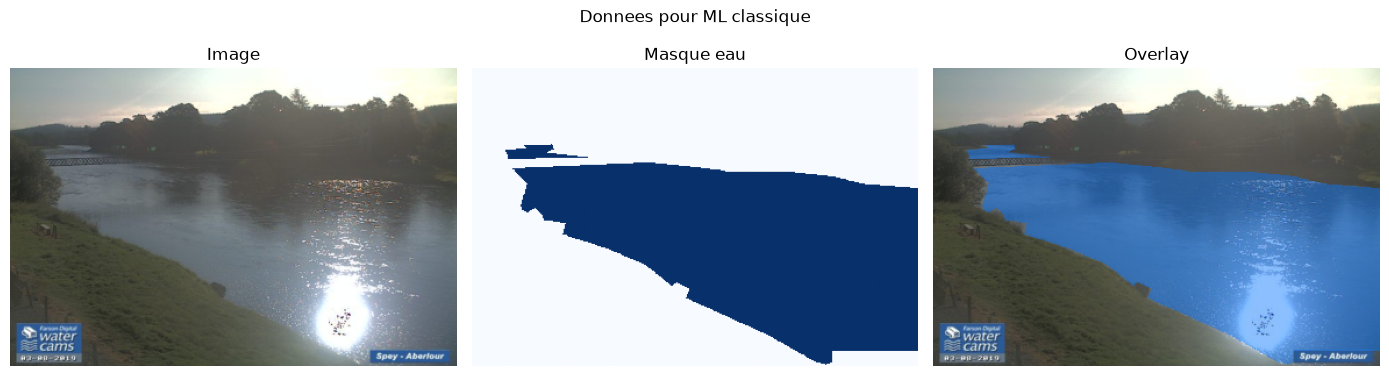

In [2]:
pairs = find_water_v2_pairs(ROOT / "water_v2")
image, mask = load_pair(*pairs[0], size=(384, 256))

pixels = image.reshape(-1, 3)
labels = mask.reshape(-1)

print("X:", pixels.shape)
print("y:", labels.shape)
print("Ratio eau:", labels.mean())
show_image_mask_overlay(image, mask, title="Donnees pour ML classique")

In [3]:
import cv2

FEATURE_COLUMNS = ["Red", "Green", "Blue", "Hue", "Saturation", "Value"]

def image_to_rgb_hsv_dataframe(image: np.ndarray) -> pd.DataFrame:
    """
    Convertit une image RGB en dataframe de features pixel-level.

    Entree
    ------
    image : array de dimensions (H, W, 3)
        Image RGB. Elle peut etre en [0, 1] comme avec load_pair,
        ou en [0, 255] si elle est deja en uint8.

    Sortie
    ------
    X : DataFrame de dimensions (H * W, 6)
        Colonnes : Red, Green, Blue, Hue, Saturation, Value.
    """
    image = np.asarray(image)

    if image.ndim != 3 or image.shape[2] != 3:
        raise ValueError("image doit avoir la forme (H, W, 3).")

    # load_pair retourne une image float en [0, 1]. OpenCV attend uint8 pour HSV.
    if image.dtype != np.uint8:
        image_rgb = (np.clip(image, 0, 1) * 255).astype(np.uint8)
    else:
        image_rgb = image

    image_hsv = cv2.cvtColor(image_rgb, cv2.COLOR_RGB2HSV)

    rgb_features = image_rgb.reshape(-1, 3)
    hsv_features = image_hsv.reshape(-1, 3)
    features = np.concatenate([rgb_features, hsv_features], axis=1)

    return pd.DataFrame(features, columns=FEATURE_COLUMNS)


def mask_to_column_vector(mask: np.ndarray) -> np.ndarray:
    """
    Convertit un masque 2D en vecteur colonne.

    Entree : mask de dimensions (H, W)
    Sortie : Y de dimensions (H * W, 1)
    """
    mask = np.asarray(mask)

    if mask.ndim == 3:
        mask = mask.squeeze()

    if mask.ndim != 2:
        raise ValueError("mask doit avoir la forme (H, W).")

    return mask.astype(np.uint8).reshape(-1, 1)


# Exemple sur une image annotee
image, mask = load_pair(*pairs[0], size=(384, 256))

X = image_to_rgb_hsv_dataframe(image)
Y = mask_to_column_vector(mask)

H, W = mask.shape

print("Image shape:", image.shape)
print("Mask shape:", mask.shape)
print("X shape:", X.shape)      # attendu : (H * W, 6)
print("Y shape:", Y.shape)      # attendu : (H * W, 1)

assert X.shape == (H * W, 6)
assert Y.shape == (H * W, 1)

display(X.head())

Image shape: (256, 384, 3)
Mask shape: (256, 384)
X shape: (98304, 6)
Y shape: (98304, 1)


,Red,Green,Blue,Hue,Saturation,Value
0,128,145,152,99,40,152
1,129,146,153,99,40,153
2,129,147,154,98,41,154
3,129,148,154,97,41,154
4,130,149,155,97,41,155


## Construction du dataset pixel-level

On construit maintenant un dataset supervise pixel par pixel.

Pour chaque paire `(image, mask)` :

- `X_img` contient les features RGB + HSV de tous les pixels de l'image ;
- `Y_img` contient les labels du masque correspondant ;
- la ligne `i` de `X_img` correspond toujours a la ligne `i` de `Y_img`.

Ensuite, on concatene toutes les images dans le meme ordre pour obtenir :

- `X_all` de dimensions `(nombre_total_pixels, 6)` ;
- `Y_all` de dimensions `(nombre_total_pixels, 1)`.

In [4]:
def build_pixel_level_dataset(
    pairs,
    size=(384, 256),
    max_images=None,
    max_pixels_per_image=None,
    seed=42,
) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    """
    Construit X_all et Y_all a partir de plusieurs paires image/masque.

    Important : l'ordre est conserve.
    La ligne k de X_all correspond exactement a la ligne k de Y_all.

    Parametres
    ----------
    pairs : list[(image_path, mask_path)]
        Paires image/masque retournees par find_water_v2_pairs.

    size : tuple
        Taille commune utilisee pour redimensionner image et masque.

    max_images : int ou None
        Nombre maximal d'images a utiliser. Mettre None pour utiliser toutes les images.

    max_pixels_per_image : int ou None
        Si None, on garde tous les pixels de chaque image.
        Si un entier est donne, on echantillonne ce nombre de pixels par image.
        C'est utile pour eviter un dataset trop lourd en memoire.

    Retour
    ------
    X_all : DataFrame, shape = (N, 6)
    Y_all : ndarray, shape = (N, 1)
    dataset_index : DataFrame
        Table indiquant quelles lignes de X_all/Y_all viennent de quelle image.
    """
    rng = np.random.default_rng(seed)

    selected_pairs = pairs if max_images is None else pairs[:max_images]

    X_parts = []
    Y_parts = []
    index_rows = []
    start_row = 0

    for image_index, (image_path, mask_path) in enumerate(selected_pairs):
        image, mask = load_pair(image_path, mask_path, size=size)

        X_img = image_to_rgb_hsv_dataframe(image)
        Y_img = mask_to_column_vector(mask)

        if len(X_img) != len(Y_img):
            raise ValueError(f"Nombre de pixels different pour {image_path.name} et son masque.")

        if max_pixels_per_image is not None and max_pixels_per_image < len(Y_img):
            sampled_indices = rng.choice(len(Y_img), size=max_pixels_per_image, replace=False)
            sampled_indices.sort()  # garde un ordre stable dans l'image
            X_img = X_img.iloc[sampled_indices].reset_index(drop=True)
            Y_img = Y_img[sampled_indices]

        X_parts.append(X_img)
        Y_parts.append(Y_img)

        end_row = start_row + len(Y_img)
        index_rows.append(
            {
                "image_index": image_index,
                "image_path": str(image_path),
                "mask_path": str(mask_path),
                "start_row": start_row,
                "end_row": end_row,
                "num_pixels": len(Y_img),
                "water_ratio": float(Y_img.mean()),
            }
        )
        start_row = end_row

    X_all = pd.concat(X_parts, ignore_index=True)
    Y_all = np.vstack(Y_parts).astype(np.uint8)
    dataset_index = pd.DataFrame(index_rows)

    return X_all, Y_all, dataset_index

In [10]:
from sklearn.model_selection import train_test_split

# Parametres principaux
SIZE = (384, 256)
MAX_IMAGES = None              # mettre None pour utiliser toutes les images disponibles
MAX_PIXELS_PER_IMAGE = 50_000  # None = garder tous les pixels de chaque image
TEST_SIZE = 0.2

# On limite d'abord le nombre d'images si besoin, puis on split au niveau image.
pairs_for_model = pairs if MAX_IMAGES is None else pairs[:MAX_IMAGES]

train_pairs, test_pairs = train_test_split(
    pairs_for_model,
    test_size=TEST_SIZE,
    random_state=42,
    shuffle=True,
)

print("Nombre total de paires utilisees:", len(pairs_for_model))
print("Nombre d'images train:", len(train_pairs))
print("Nombre d'images test :", len(test_pairs))

Nombre total de paires utilisees: 2400
Nombre d'images train: 1920
Nombre d'images test : 480


 Construction de `X_train`, `y_train`, `X_test`, `y_test`

A partir de `train_pairs`, on construit les pixels d'entrainement.

A partir de `test_pairs`, on construit les pixels de test.

Ainsi, les pixels du test viennent uniquement d'images jamais vues pendant l'entrainement.

In [11]:
X_train, Y_train, train_index = build_pixel_level_dataset(
    train_pairs,
    size=SIZE,
    max_images=None,
    max_pixels_per_image=MAX_PIXELS_PER_IMAGE,
    seed=42,
)

X_test, Y_test, test_index = build_pixel_level_dataset(
    test_pairs,
    size=SIZE,
    max_images=None,
    max_pixels_per_image=MAX_PIXELS_PER_IMAGE,
    seed=123,
)

# scikit-learn attend souvent y sous la forme (N,), donc on transforme Y en vecteur 1D.
y_train = Y_train.ravel()
y_test = Y_test.ravel()

print("X_train:", X_train.shape)
print("y_train:", y_train.shape)
print("X_test :", X_test.shape)
print("y_test :", y_test.shape)
print("Ratio eau train:", float(y_train.mean()))
print("Ratio eau test :", float(y_test.mean()))

assert X_train.shape[0] == y_train.shape[0]
assert X_test.shape[0] == y_test.shape[0]
assert X_train.shape[1] == 6
assert X_test.shape[1] == 6

display(X_train.head()) # type: ignore
display(train_index.head()) # type: ignore
display(test_index.head()) # type: ignore

X_train: (96000000, 6)
y_train: (96000000,)
X_test : (24000000, 6)
y_test : (24000000,)
Ratio eau train: 0.25904958333333333
Ratio eau test : 0.25958575


,Red,Green,Blue,Hue,Saturation,Value
0,200,222,245,105,47,245
1,201,223,246,105,47,246
2,204,226,249,105,46,249
3,202,224,247,105,46,247
4,198,220,243,105,47,243


,image_index,image_path,mask_path,start_row,end_row,num_pixels,water_ratio
0,0,c:\Users\Asus\Desktop\OCP\water-detection-meth...,c:\Users\Asus\Desktop\OCP\water-detection-meth...,0,50000,50000,0.30742
1,1,c:\Users\Asus\Desktop\OCP\water-detection-meth...,c:\Users\Asus\Desktop\OCP\water-detection-meth...,50000,100000,50000,0.00236
2,2,c:\Users\Asus\Desktop\OCP\water-detection-meth...,c:\Users\Asus\Desktop\OCP\water-detection-meth...,100000,150000,50000,0.33586
3,3,c:\Users\Asus\Desktop\OCP\water-detection-meth...,c:\Users\Asus\Desktop\OCP\water-detection-meth...,150000,200000,50000,0.38670
4,4,c:\Users\Asus\Desktop\OCP\water-detection-meth...,c:\Users\Asus\Desktop\OCP\water-detection-meth...,200000,250000,50000,0.05164


,image_index,image_path,mask_path,start_row,end_row,num_pixels,water_ratio
0,0,c:\Users\Asus\Desktop\OCP\water-detection-meth...,c:\Users\Asus\Desktop\OCP\water-detection-meth...,0,50000,50000,0.48184
1,1,c:\Users\Asus\Desktop\OCP\water-detection-meth...,c:\Users\Asus\Desktop\OCP\water-detection-meth...,50000,100000,50000,0.17962
2,2,c:\Users\Asus\Desktop\OCP\water-detection-meth...,c:\Users\Asus\Desktop\OCP\water-detection-meth...,100000,150000,50000,0.15126
3,3,c:\Users\Asus\Desktop\OCP\water-detection-meth...,c:\Users\Asus\Desktop\OCP\water-detection-meth...,150000,200000,50000,0.91392
4,4,c:\Users\Asus\Desktop\OCP\water-detection-meth...,c:\Users\Asus\Desktop\OCP\water-detection-meth...,200000,250000,50000,0.25858


## Donnees pretes pour l'entrainement

On a maintenant :

- `X_train` : features RGB + HSV des pixels des images d'entrainement ;
- `y_train` : labels eau/non-eau correspondants ;
- `X_test` : features RGB + HSV des pixels des images de test ;
- `y_test` : labels eau/non-eau correspondants.

Ces variables peuvent etre utilisees directement pour entrainer Logistic Regression, SVM ou Decision Tree.

In [12]:
from time import perf_counter

from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
)
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import LinearSVC
from sklearn.tree import DecisionTreeClassifier


# Pixel-level datasets can become very large. Keep this value for fast,
# reproducible classical ML experiments, or set it to None to train on all
# pixels from the training images.
TRAIN_SAMPLE_SIZE = 250_000
RANDOM_STATE = 42

rng = np.random.default_rng(RANDOM_STATE)
if TRAIN_SAMPLE_SIZE is not None and TRAIN_SAMPLE_SIZE < len(y_train):
    train_indices = rng.choice(len(y_train), size=TRAIN_SAMPLE_SIZE, replace=False)
    X_fit = X_train.iloc[train_indices]
    y_fit = y_train[train_indices]
else:
    X_fit = X_train
    y_fit = y_train

print(f"Pixels used for training: {len(y_fit):,} / {len(y_train):,}")
print(f"Pixels used for testing : {len(y_test):,}")

models = {
    "Logistic Regression": make_pipeline(
        StandardScaler(),
        LogisticRegression(
            max_iter=1000,
            class_weight="balanced",
            random_state=RANDOM_STATE,
            n_jobs=-1,
        ),
    ),
    "Linear SVM": make_pipeline(
        StandardScaler(),
        LinearSVC(
            class_weight="balanced",
            random_state=RANDOM_STATE,
            max_iter=5000,
        ),
    ),
    "Decision Tree": DecisionTreeClassifier(
        max_depth=20,
        min_samples_leaf=50,
        class_weight="balanced",
        random_state=RANDOM_STATE,
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=80,
        max_depth=20,
        min_samples_leaf=20,
        class_weight="balanced_subsample",
        random_state=RANDOM_STATE,
        n_jobs=-1,
    ),
}

trained_models = {}
predictions = {}
metric_rows = []

for model_name, model in models.items():
    print(f"\nTraining {model_name}...")
    start = perf_counter()
    model.fit(X_fit, y_fit)
    train_seconds = perf_counter() - start

    start = perf_counter()
    y_pred = model.predict(X_test)
    predict_seconds = perf_counter() - start

    tn, fp, fn, tp = confusion_matrix(y_test, y_pred, labels=[0, 1]).ravel()

    trained_models[model_name] = model
    predictions[model_name] = y_pred
    metric_rows.append(
        {
            "model": model_name,
            "accuracy": accuracy_score(y_test, y_pred),
            "precision_water": precision_score(y_test, y_pred, zero_division=0),
            "recall_water": recall_score(y_test, y_pred, zero_division=0),
            "f1_water": f1_score(y_test, y_pred, zero_division=0),
            "iou_water": intersection_over_union(y_test, y_pred),
            "dice_water": dice_coefficient(y_test, y_pred),
            "tn": tn,
            "fp": fp,
            "fn": fn,
            "tp": tp,
            "train_seconds": train_seconds,
            "predict_seconds": predict_seconds,
        }
    )

metrics_df = (
    pd.DataFrame(metric_rows)
    .sort_values("iou_water", ascending=False)
    .reset_index(drop=True)
)

display(metrics_df)

for model_name in metrics_df["model"]:
    print(f"\nClassification report - {model_name}")
    print(
        classification_report(
            y_test,
            predictions[model_name],
            target_names=["non_water", "water"],
            zero_division=0,
        )
    )


Pixels used for training: 250,000 / 96,000,000
Pixels used for testing : 24,000,000

Training Logistic Regression...


c:\Users\Asus\Desktop\OCP\water-detection-methods\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1457: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)



Training Linear SVM...

Training Decision Tree...

Training Random Forest...


,model,accuracy,precision_water,recall_water,f1_water,iou_water,dice_water,tn,fp,fn,tp,train_seconds,predict_seconds
0,Random Forest,0.669971,0.400401,0.545470,0.461811,0.300230,0.461811,12680992,5088950,2831751,3398307,3.531029,37.359148
1,Decision Tree,0.635274,0.370958,0.582169,0.453161,0.292960,0.453161,11619631,6150311,2603109,3626949,0.728903,1.979995
2,Linear SVM,0.531645,0.310133,0.656833,0.421330,0.266889,0.421330,8667382,9102560,2137951,4092107,0.277431,0.866210
3,Logistic Regression,0.529982,0.309581,0.658971,0.421258,0.266831,0.421258,8614138,9155804,2124630,4105428,0.177913,1.148977



Classification report - Random Forest
              precision    recall  f1-score   support

   non_water       0.82      0.71      0.76  17769942
       water       0.40      0.55      0.46   6230058

    accuracy                           0.67  24000000
   macro avg       0.61      0.63      0.61  24000000
weighted avg       0.71      0.67      0.68  24000000


Classification report - Decision Tree
              precision    recall  f1-score   support

   non_water       0.82      0.65      0.73  17769942
       water       0.37      0.58      0.45   6230058

    accuracy                           0.64  24000000
   macro avg       0.59      0.62      0.59  24000000
weighted avg       0.70      0.64      0.66  24000000


Classification report - Linear SVM
              precision    recall  f1-score   support

   non_water       0.80      0.49      0.61  17769942
       water       0.31      0.66      0.42   6230058

    accuracy                           0.53  24000000
   macro avg  

## Prediction visuelle sur une paire image/masque

La fonction suivante applique un modele entraine a une image complete. Elle reconstruit le vecteur de predictions pixel par pixel en masque 2D, puis affiche :

- image originale ;
- masque reel ;
- masque predit par le modele.


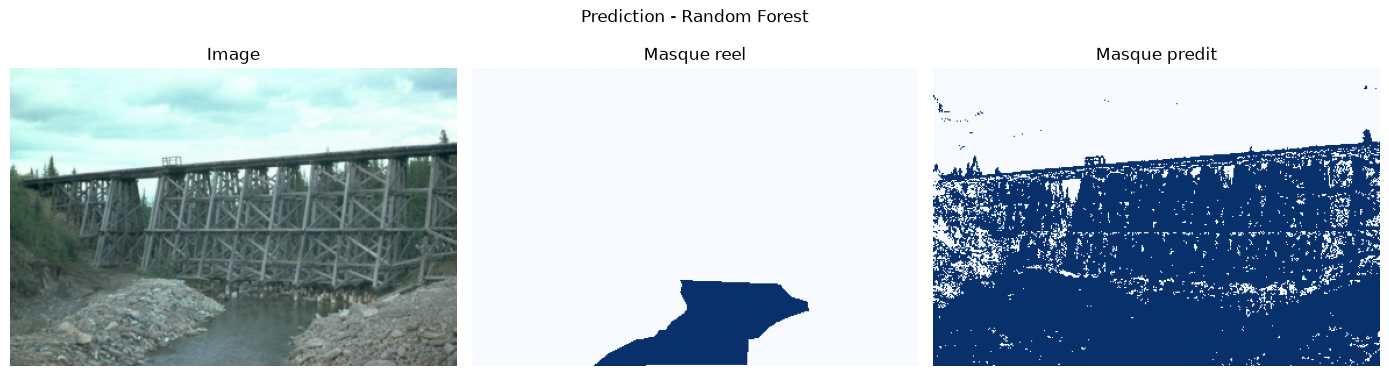

In [19]:
import matplotlib.pyplot as plt


def predire_et_afficher_masque(model, pair, size=SIZE, title=None):
    """Predit et affiche le masque d eau pour une paire image/masque.

    Parametres
    ----------
    model : estimateur scikit-learn entraine
        Modele qui possede une methode predict et qui attend les colonnes
        Red, Green, Blue, Hue, Saturation, Value.

    pair : tuple(image_path, mask_path)
        Couple image/masque, par exemple un element de train_pairs ou test_pairs.

    size : tuple
        Taille utilisee pour charger l image et le masque. Elle doit etre la
        meme que celle utilisee pendant l entrainement.

    title : str ou None
        Titre optionnel de la figure.

    Retour
    ------
    pred_mask_image : ndarray, shape = (H, W), dtype = uint8
        Masque predit sous forme d image binaire avec 0 = fond et 255 = eau.
    """
    image_path, mask_path = pair
    image, true_mask = load_pair(image_path, mask_path, size=size)

    X_image = image_to_rgb_hsv_dataframe(image)
    y_pred = model.predict(X_image)

    pred_mask = y_pred.astype(np.uint8).reshape(true_mask.shape)
    pred_mask_image = (pred_mask * 255).astype(np.uint8)

    fig, axes = plt.subplots(1, 3, figsize=(14, 4))

    axes[0].imshow(image)
    axes[0].set_title("Image")
    axes[0].axis("off")

    axes[1].imshow(true_mask, cmap="Blues", vmin=0, vmax=1)
    axes[1].set_title("Masque reel")
    axes[1].axis("off")

    axes[2].imshow(pred_mask_image, cmap="Blues", vmin=0, vmax=255)
    axes[2].set_title("Masque predit")
    axes[2].axis("off")

    if title is not None:
        fig.suptitle(title)

    plt.tight_layout()
    plt.show()

    return pred_mask_image


# Exemple avec le meilleur modele selon IoU, sur une image de test.
best_model_name = metrics_df.iloc[0]["model"]
best_model = trained_models[best_model_name]

pred_mask_image = predire_et_afficher_masque(
    best_model,
    test_pairs[50],
    size=SIZE,
    title=f"Prediction - {best_model_name}",
)
